# Lecture 6: AS-AD Dynamics And Energy Price Shocks

**Macroeconomics B -- Chapter 19**

By the end of this notebook you will be able to:
1. Simulate the AS-AD model with static expectations.
2. Compare demand and supply shocks using output and inflation gaps.
3. Use an energy supply shock to evaluate policy trade-offs.

**Table of contents**<a id='toc0_'></a>
- 1. [AS-AD With Static Expectations](#toc1_)
- 2. [Persistence And The Policy Response](#toc2_)
- 3. [Demand Versus Supply Shocks](#toc3_)
- 4. [Group Exercise: Energy Supply Shock](#toc4_)
- 5. [Summary](#toc5_)
- 6. [Energy Prices And Euro-Area Inflation](#toc6_)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lecture_06_notebook_utils import (
    annual_percentage_change,
    fallback_monthly_series,
    fetch_fred_series,
    simulate_as_ad,
)

plt.rcParams.update({'axes.grid': True, 'grid.color': 'black',
                     'grid.alpha': 0.25, 'grid.linestyle': '--'})
plt.rcParams.update({'font.size': 14})

rng = np.random.default_rng(2025)
FRED_API_KEY = "9fb7818ec505ebe0f36e58efc607471c"

## 1. <a id='toc1_'></a>[AS-AD With Static Expectations](#toc0_)

The lecture model has two equations in gaps:

$$
\widehat y_t = z_t-a\widehat\pi_t,
\qquad
\widehat\pi_t = \widehat\pi_{t-1}+\gamma\widehat y_t+s_t.
$$

The demand shock is $z_t$. The supply shock is $s_t$. Energy price shocks enter most naturally as $s_t>0$, because they raise production costs at a given level of output.

In [2]:
params = {
    "T": 12,
    "gamma": 0.5,
    "a": 0.75,
    "s1": 1.0,
    "z1": 1.0,
}

s_path = np.zeros(params["T"])
s_path[0] = params["s1"]

baseline_supply = simulate_as_ad(
    T=params["T"],
    a=params["a"],
    gamma=params["gamma"],
    s_path=s_path,
)

baseline_supply.head()

,period,output_gap,inflation_gap,supply_shock,demand_shock
0,1,-0.545455,0.727273,1.0,0.0
1,2,-0.396694,0.528926,0.0,0.0
2,3,-0.288505,0.384673,0.0,0.0
3,4,-0.209822,0.279762,0.0,0.0
4,5,-0.152598,0.203463,0.0,0.0


The first row is the impact period. In this calibration, the adverse supply shock raises inflation and lowers output immediately.

## 2. <a id='toc2_'></a>[Persistence And The Policy Response](#toc0_)

The persistence coefficient is

$$
\beta=\frac{1}{1+a\gamma}.
$$

A higher value of $a$ means that inflation deviations create a stronger demand response through policy and real interest rates. This lowers $\beta$ and makes convergence faster.

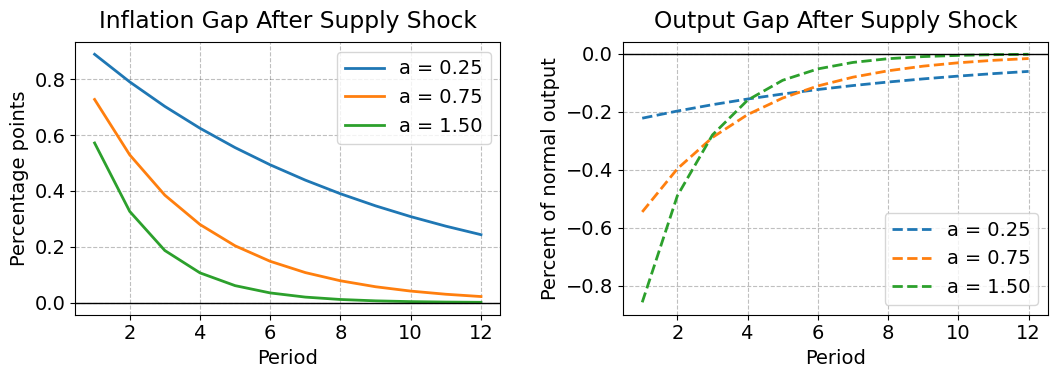

In [3]:
a_values = [0.25, 0.75, 1.50]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig = plt.figure(figsize=(11, 4))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

for i, a in enumerate(a_values):
    s_path = np.zeros(params["T"])
    s_path[0] = params["s1"]
    sim = simulate_as_ad(T=params["T"], a=a, gamma=params["gamma"], s_path=s_path)
    label = f"a = {a:.2f}"
    ax1.plot(sim["period"], sim["inflation_gap"], color=colors[i], ls='-', lw=2, label=label)
    ax2.plot(sim["period"], sim["output_gap"], color=colors[i], ls='--', lw=2, label=label)

ax1.axhline(0, color='black', lw=1)
ax2.axhline(0, color='black', lw=1)
ax1.set_title('Inflation Gap After Supply Shock', pad=10)
ax2.set_title('Output Gap After Supply Shock', pad=10)
ax1.set_xlabel('Period')
ax2.set_xlabel('Period')
ax1.set_ylabel('Percentage points')
ax2.set_ylabel('Percent of normal output')
ax1.legend(loc='upper right')
ax2.legend(loc='lower right')
fig.tight_layout()

A stronger inflation response makes inflation return faster, but it also creates a larger initial output loss. The model makes the trade-off visible.

## 3. <a id='toc3_'></a>[Demand Versus Supply Shocks](#toc0_)

Demand shocks move output and inflation in the same direction on impact. Supply shocks move them in opposite directions. This sign pattern is the fastest way to classify an episode before adding institutional detail.

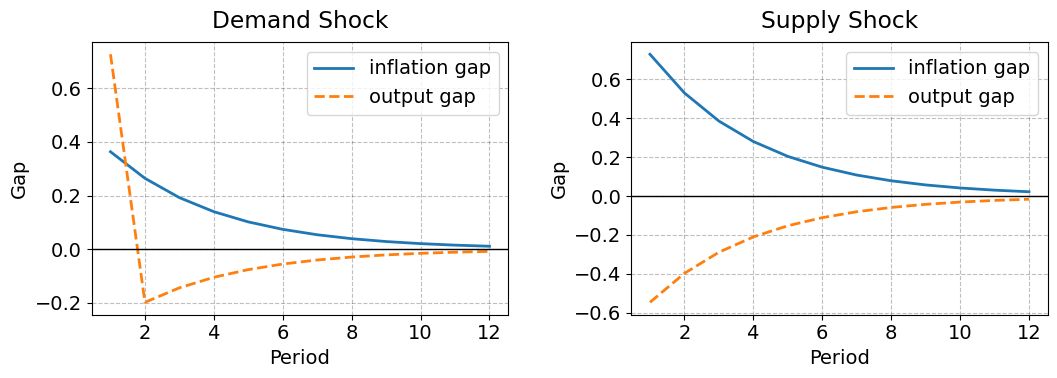

In [4]:
z_path = np.zeros(params["T"])
z_path[0] = params["z1"]
s_path = np.zeros(params["T"])
s_path[0] = params["s1"]

demand_sim = simulate_as_ad(T=params["T"], a=params["a"], gamma=params["gamma"], z_path=z_path)
supply_sim = simulate_as_ad(T=params["T"], a=params["a"], gamma=params["gamma"], s_path=s_path)

fig = plt.figure(figsize=(11, 4))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

ax1.plot(demand_sim["period"], demand_sim["inflation_gap"], color=colors[0], ls='-', lw=2, label='inflation gap')
ax1.plot(demand_sim["period"], demand_sim["output_gap"], color=colors[1], ls='--', lw=2, label='output gap')
ax2.plot(supply_sim["period"], supply_sim["inflation_gap"], color=colors[0], ls='-', lw=2, label='inflation gap')
ax2.plot(supply_sim["period"], supply_sim["output_gap"], color=colors[1], ls='--', lw=2, label='output gap')

for ax, title in zip([ax1, ax2], ['Demand Shock', 'Supply Shock']):
    ax.axhline(0, color='black', lw=1)
    ax.set_title(title, pad=10)
    ax.set_xlabel('Period')
    ax.set_ylabel('Gap')
    ax.legend(loc='best')

fig.tight_layout()

The demand shock produces same-sign movement. The supply shock produces stagflation on impact: inflation rises while output falls. This code is for understanding shock classification; the group policy exercise uses the dedicated code cell in Section 4.


## 4. <a id='toc4_'></a>[Group Exercise: Energy Supply Shock](#toc0_)

Work in groups of 2-4. Your group is assigned one policy-response value:

| Group | Assigned value | Policy idea |
|---|---:|---|
| A | $a=1.50$ | Strong inflation stabilization |
| B | $a=0.25$ | Limit the output loss |
| C | $a=0.75$ | Compromise between inflation and output |

Use the dedicated code cell directly below this text. Do not change the Section 3 demand-versus-supply-shock code; that cell is only for classifying shocks by sign patterns.

In the code below, replace `assigned_a` with your group's value. Run the cell to compare $s_1=1.0$ and $s_1=2.0$. Focus on the impact inflation gap, the impact output gap, and $\beta$.

Before we discuss as a class, write down:

1. Which value of $a$ your group used.
2. What happens to the impact inflation gap and output gap when $s_1$ doubles.
3. One sentence defending your assigned policy idea.


In [5]:
# Group exercise code: change assigned_a to your group's value.
assigned_a = 0.75  # Group A: 1.50, Group B: 0.25, Group C: 0.75
shock_sizes = [1.0, 2.0]

rows = []
for shock_size in shock_sizes:
    s_path = np.zeros(params["T"])
    s_path[0] = shock_size
    sim = simulate_as_ad(
        T=params["T"],
        a=assigned_a,
        gamma=params["gamma"],
        s_path=s_path,
    )
    beta = 1 / (1 + assigned_a * params["gamma"])
    impact = sim.iloc[0]
    rows.append({
        "s1": shock_size,
        "a": assigned_a,
        "beta": beta,
        "impact_inflation_gap": impact["inflation_gap"],
        "impact_output_gap": impact["output_gap"],
    })

pd.DataFrame(rows)


,s1,a,beta,impact_inflation_gap,impact_output_gap
0,1.0,0.75,0.727273,0.727273,-0.545455
1,2.0,0.75,0.727273,1.454545,-1.090909


## 5. <a id='toc5_'></a>[Summary](#toc0_)

| Object | Equation | Interpretation |
|---|---|---|
| AD | $\widehat y_t=z_t-a\widehat\pi_t$ | Demand falls when inflation triggers higher real rates. |
| AS | $\widehat\pi_t=\widehat\pi_{t-1}+\gamma\widehat y_t+s_t$ | Inflation reflects inherited inflation, output pressure, and supply costs. |
| Persistence | $\beta=1/(1+a\gamma)$ | Lower $\beta$ means faster convergence. |
| Supply shock impact | $\widehat\pi_1=\beta s_1,\ \widehat y_1=-a\beta s_1$ | Inflation rises and output falls. |
| Group exercise | Compare assigned $a$ values | Use the dedicated group-exercise code cell in Section 4. |

The 2022 energy shock is a useful case because the supply-shock trade-off is visible in both the model and the data. The final section connects this model reading to energy-price and inflation data.


## 6. <a id='toc6_'></a>[Energy Prices And Euro-Area Inflation](#toc0_)

This data section comes at the end because it supports the economic interpretation after the model exercise. It downloads FRED series for European natural gas prices and euro-area HICP. If the live download is unavailable, the cell uses fallback values so the notebook remains executable in class.


In [6]:
fallback_dates = pd.date_range(start='2020-01-01', periods=72, freq='MS')
trend = np.linspace(0, 1, len(fallback_dates))
shock_shape = np.exp(-0.5 * ((np.arange(len(fallback_dates)) - 31) / 5) ** 2)
second_shape = np.exp(-0.5 * ((np.arange(len(fallback_dates)) - 37) / 7) ** 2)

gas_fallback = fallback_monthly_series(8 + 10 * trend + 245 * shock_shape + 45 * second_shape, '2020-01-01', 'PNGASEUUSDM')
energy_hicp_fallback = fallback_monthly_series(100 + 1.2 * np.arange(72) + 32 * second_shape, '2020-01-01', 'ENRGY0EZ19M086NEST')
all_hicp_fallback = fallback_monthly_series(100 + 0.35 * np.arange(72) + 8 * second_shape, '2020-01-01', 'CP0000EZ19M086NEST')

gas = fetch_fred_series('PNGASEUUSDM', FRED_API_KEY, start='2020-01-01', fallback=gas_fallback)
energy_hicp = fetch_fred_series('ENRGY0EZ19M086NEST', FRED_API_KEY, start='2020-01-01', fallback=energy_hicp_fallback)
all_hicp = fetch_fred_series('CP0000EZ19M086NEST', FRED_API_KEY, start='2020-01-01', fallback=all_hicp_fallback)

energy_inflation = annual_percentage_change(energy_hicp)
headline_inflation = annual_percentage_change(all_hicp)

data = pd.concat([
    gas.rename('Natural gas price'),
    energy_inflation.rename('Energy inflation'),
    headline_inflation.rename('Headline inflation'),
], axis=1).dropna()

data.tail()

,Natural gas price,Energy inflation,Headline inflation
2025-11-01,10.355,-0.539299,2.114681
2025-12-01,9.460,-1.995037,1.934961
2026-01-01,11.987,-4.048973,1.635680
2026-02-01,11.190,-3.191181,1.871523
2026-03-01,17.670,5.060808,2.533682


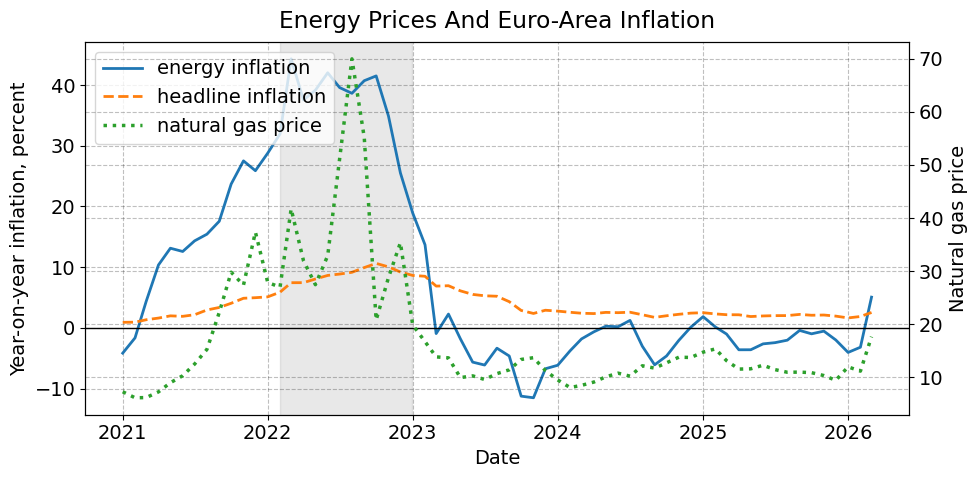

In [7]:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(1, 1, 1)
ax2 = ax1.twinx()

ax1.plot(data.index, data['Energy inflation'], color=colors[0], ls='-', lw=2, label='energy inflation')
ax1.plot(data.index, data['Headline inflation'], color=colors[1], ls='--', lw=2, label='headline inflation')
ax2.plot(data.index, data['Natural gas price'], color=colors[2], ls=':', lw=2.5, label='natural gas price')

ax1.axhline(0, color='black', lw=1)
ax1.axvspan(pd.Timestamp('2022-02-01'), pd.Timestamp('2022-12-31'), color='grey', alpha=0.18)
ax1.set_title('Energy Prices And Euro-Area Inflation', pad=10)
ax1.set_xlabel('Date')
ax1.set_ylabel('Year-on-year inflation, percent')
ax2.set_ylabel('Natural gas price')

handles, labels = [], []
for axis in [ax1, ax2]:
    axis_handles, axis_labels = axis.get_legend_handles_labels()
    for handle, label in zip(axis_handles, axis_labels):
        if label and not label.startswith('_'):
            handles.append(handle)
            labels.append(label)
ax1.legend(handles, labels, loc='upper left')
fig.tight_layout()

The shaded area marks 2022. The model reads the energy-price surge as an adverse supply shock that pushes inflation above target and squeezes output.